# Telecom X — Análise de Churn (ETL + EDA)

**Objetivo:** fluxo completo **Extração → Limpeza → Transformação → EDA**.

**Fonte:** JSON via URL `ingridcristh/challenge2-data-science`

---

## Sumário
1. Imports e Configuração
2. Extração (E)
3. Inspeção Inicial
4. Limpeza (T)
5. Transformação (T)
6. EDA — Análises e Visualizações
7. Insights e Recomendações

---
## 1) Imports e Configuração

In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

os.makedirs("graficos", exist_ok=True)
print("Ambiente pronto.")

Ambiente pronto.


---
## 2) Extração (E)

Carregamos o JSON da URL e usamos `pd.json_normalize` para "achatar" o dicionário
aninhado em um DataFrame tabular. As colunas resultantes seguem o padrão `grupo.campo`
(ex.: `customer.gender`, `account.Charges.Monthly`).

In [2]:
URL = (
    "https://raw.githubusercontent.com/ingridcristh/"
    "challenge2-data-science/refs/heads/main/TelecomX_Data.json"
)

resp = requests.get(URL, timeout=60)
resp.raise_for_status()

df_raw = pd.json_normalize(resp.json())
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


---
## 3) Inspeção Inicial

Avaliamos tipos de dados, nulos, duplicados e estatísticas descritivas iniciais.

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [4]:
print("=== Nulos por coluna ===")
print(df_raw.isna().sum().sort_values(ascending=False))
print(f"\nDuplicados: {df_raw.duplicated().sum()}")

=== Nulos por coluna ===
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64

Duplicados: 0


In [5]:
df_raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7267,7267,9995-HOTOH,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,7267,3,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer.gender,7267,2,Male,3675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer.SeniorCitizen,7267.0,NaN,NaN,NaN,0.162653,0.369074,0.0,0.0,0.0,0.0,1.0
customer.Partner,7267,2,No,3749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer.Dependents,7267,2,No,5086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer.tenure,7267.0,NaN,NaN,NaN,32.346498,24.571773,0.0,9.0,29.0,55.0,72.0
phone.PhoneService,7267,2,Yes,6560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
phone.MultipleLines,7267,3,No,3495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
internet.InternetService,7267,3,Fiber optic,3198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4) Limpeza (T)

1. `account.Charges.Total` chega como **string** → converter para `float`.
2. Remover linhas nulas geradas pela conversão.
3. Remover duplicados.

In [6]:
df = df_raw.copy()

# account.Charges.Total vem como object; forçar conversão numérica
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"], errors="coerce"
)

antes = len(df)
df = df.dropna(subset=["account.Charges.Total"]).drop_duplicates().reset_index(drop=True)
depois = len(df)
print(f"Linhas: {antes} -> {depois}  (removidas: {antes - depois})")

Linhas: 7267 -> 7256  (removidas: 11)


In [7]:
# Confirmar ausencia de nulos remanescentes
print(df.isna().sum().sort_values(ascending=False).head(10))

customerID                  0
Churn                       0
customer.gender             0
customer.SeniorCitizen      0
customer.Partner            0
customer.Dependents         0
customer.tenure             0
phone.PhoneService          0
phone.MultipleLines         0
internet.InternetService    0
dtype: int64


---
## 5) Transformação (T)

### 5.1 Renomear colunas

Mapeamos os nomes gerados pelo `json_normalize` (ex.: `customer.gender`)
para nomes em português. **Importante:** o mapa deve usar os nomes com prefixo,
pois é assim que o `json_normalize` os produz.

In [8]:
RENAME = {
    # raiz
    "customerID":                 "ID_Cliente",
    "Churn":                      "Churn",
    # grupo customer
    "customer.gender":            "Genero",
    "customer.SeniorCitizen":     "Idoso",
    "customer.Partner":           "Possui_Parceiro",
    "customer.Dependents":        "Possui_Dependentes",
    "customer.tenure":            "Tempo_Contrato_Meses",
    # grupo phone
    "phone.PhoneService":         "Servico_Telefone",
    "phone.MultipleLines":        "Multiplas_Linhas",
    # grupo internet
    "internet.InternetService":   "Servico_Internet",
    "internet.OnlineSecurity":    "Seguranca_Online",
    "internet.OnlineBackup":      "Backup_Online",
    "internet.DeviceProtection":  "Protecao_Dispositivo",
    "internet.TechSupport":       "Suporte_Tecnico",
    "internet.StreamingTV":       "Streaming_TV",
    "internet.StreamingMovies":   "Streaming_Filmes",
    # grupo account
    "account.Contract":           "Tipo_Contrato",
    "account.PaperlessBilling":   "Fatura_Digital",
    "account.PaymentMethod":      "Metodo_Pagamento",
    "account.Charges.Monthly":    "Faturamento_Mensal",
    "account.Charges.Total":      "Total_Gasto",
}

df = df.rename(columns=RENAME)
print("Colunas:", df.columns.tolist())

Colunas: ['ID_Cliente', 'Churn', 'Genero', 'Idoso', 'Possui_Parceiro', 'Possui_Dependentes', 'Tempo_Contrato_Meses', 'Servico_Telefone', 'Multiplas_Linhas', 'Servico_Internet', 'Seguranca_Online', 'Backup_Online', 'Protecao_Dispositivo', 'Suporte_Tecnico', 'Streaming_TV', 'Streaming_Filmes', 'Tipo_Contrato', 'Fatura_Digital', 'Metodo_Pagamento', 'Faturamento_Mensal', 'Total_Gasto']


### 5.2 Tradução de categorias e conversão binária

- **Churn**: filtrar apenas `Yes`/`No` e converter para `1`/`0`.
- Colunas estritamente binárias (`Yes`/`No`) → `1`/`0`.
- Categorias em inglês → português (Gênero, Tipo de Contrato).

In [9]:
# Churn: filtrar valores invalidos e converter para binario
df["Churn"] = df["Churn"].astype(str).str.strip()
df = df[df["Churn"].isin(["Yes", "No"])].copy()
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(f"Clientes apos filtro de Churn: {len(df)}")
df["Churn"].value_counts()

Clientes apos filtro de Churn: 7032


Churn
0    5163
1    1869
Name: count, dtype: int64

In [10]:
# Tradução de categorias
df["Genero"] = df["Genero"].map({"Male": "Masculino", "Female": "Feminino"})

df["Tipo_Contrato"] = df["Tipo_Contrato"].map({
    "Month-to-month": "Mensal",
    "One year":        "Anual",
    "Two year":        "Bienal",
})

# Colunas estritamente Yes/No -> 1/0
YN_COLS = ["Possui_Parceiro", "Possui_Dependentes", "Servico_Telefone", "Fatura_Digital"]
for col in YN_COLS:
    df[col] = df[col].map({"Yes": 1, "No": 0})

df[["Genero", "Tipo_Contrato", "Possui_Parceiro", "Fatura_Digital", "Churn"]].head()

,Genero,Tipo_Contrato,Possui_Parceiro,Fatura_Digital,Churn
0,Feminino,Anual,1,1,0
1,Masculino,Mensal,0,0,0
2,Masculino,Mensal,0,1,1
3,Masculino,Mensal,1,1,1
4,Feminino,Mensal,1,1,1


### 5.3 Feature Engineering

**Contas_Diarias** = `Faturamento_Mensal / 30` — custo médio por dia.

In [11]:
df["Contas_Diarias"] = (df["Faturamento_Mensal"] / 30).round(2)

print(f"Shape final: {df.shape}")
df[["Faturamento_Mensal", "Contas_Diarias", "Total_Gasto"]].describe()

Shape final: (7032, 22)


,Faturamento_Mensal,Contas_Diarias,Total_Gasto
count,7032.000000,7032.000000,7032.000000
mean,64.798208,2.159891,2283.300441
std,30.085974,1.002955,2266.771362
min,18.250000,0.610000,18.800000
25%,35.587500,1.187500,401.450000
50%,70.350000,2.340000,1397.475000
75%,89.862500,2.992500,3794.737500
max,118.750000,3.960000,8684.800000


---
## 6) EDA — Análise Exploratória de Dados

### 6.0 Estatísticas Descritivas

In [12]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,7032.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Idoso,7032.0,0.16,0.37,0.00,0.00,0.00,0.00,1.00
Possui_Parceiro,7032.0,0.48,0.50,0.00,0.00,0.00,1.00,1.00
Possui_Dependentes,7032.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
Tempo_Contrato_Meses,7032.0,32.42,24.55,1.00,9.00,29.00,55.00,72.00
Servico_Telefone,7032.0,0.90,0.30,0.00,1.00,1.00,1.00,1.00
Fatura_Digital,7032.0,0.59,0.49,0.00,0.00,1.00,1.00,1.00
Faturamento_Mensal,7032.0,64.80,30.09,18.25,35.59,70.35,89.86,118.75
Total_Gasto,7032.0,2283.30,2266.77,18.80,401.45,1397.48,3794.74,8684.80
Contas_Diarias,7032.0,2.16,1.00,0.61,1.19,2.34,2.99,3.96


### 6.1 Taxa Geral de Churn

**Objetivo:** percentual de clientes que cancelaram vs. permaneceram.
Churn alto indica necessidade urgente de ações de retenção.

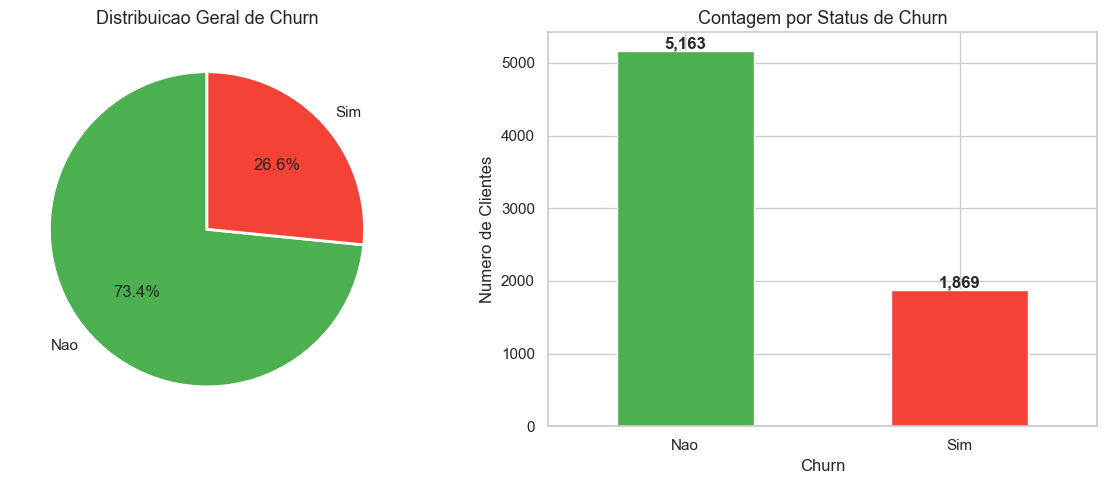

Taxa de Churn: 26.6%


In [13]:
churn_count = df["Churn"].value_counts().rename({0: "Nao", 1: "Sim"})
churn_pct   = df["Churn"].value_counts(normalize=True).rename({0: "Nao", 1: "Sim"}) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    churn_pct,
    labels=churn_pct.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#F44336"],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title("Distribuicao Geral de Churn", fontsize=13)

churn_count.plot(kind="bar", ax=axes[1], color=["#4CAF50", "#F44336"], edgecolor="white")
axes[1].set_title("Contagem por Status de Churn", fontsize=13)
axes[1].set_ylabel("Numero de Clientes")
axes[1].set_xticklabels(churn_count.index, rotation=0)
for i, v in enumerate(churn_count):
    axes[1].text(i, v + 40, f"{v:,}", ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("graficos/01_churn_geral.png", dpi=150, bbox_inches="tight")
plt.show()
taxa = churn_pct.get("Sim", 0)
print(f"Taxa de Churn: {taxa:.1f}%")

#### Função auxiliar: barras empilhadas por categoria

In [14]:
def plot_churn_por_categoria(df, col, titulo=None, figsize=(9, 4), save_path=None):
    """Barras empilhadas com proporcao de churn (%) por categoria."""
    tab = pd.crosstab(df[col], df["Churn"], normalize="index") * 100
    tab = tab.rename(columns={0: "Nao", 1: "Sim"})

    ax = tab.plot(
        kind="bar", stacked=True, figsize=figsize,
        color=["#4CAF50", "#F44336"], edgecolor="white"
    )
    ax.set_title(titulo or f"Churn por {col} (%)", fontsize=13)
    ax.set_ylabel("Proporcao (%)")
    ax.set_xlabel("")
    ax.legend(title="Churn", loc="lower right")
    plt.xticks(rotation=15, ha="right")

    for i, (_, row) in enumerate(tab.iterrows()):
        pct_sim = row.get("Sim", 0)
        ax.text(i, 50, f"{pct_sim:.1f}%",
                ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")

    if save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

### 6.2 Churn por Tipo de Contrato

**Hipotese:** contratos mensais tem menor barreira de saida -> maior churn.
**Acao esperada:** incentivar migracao para planos anuais/bienais.

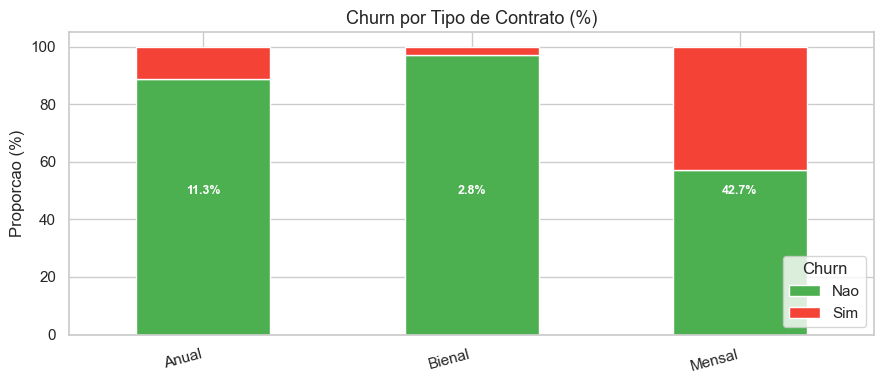

In [15]:
plot_churn_por_categoria(
    df, "Tipo_Contrato",
    titulo="Churn por Tipo de Contrato (%)",
    save_path="graficos/02_churn_por_contrato.png"
)

### 6.3 Churn por Servico de Internet

**Hipotese:** clientes com Fiber Optic podem ter maior churn se perceberem
custo-beneficio desfavoravel.

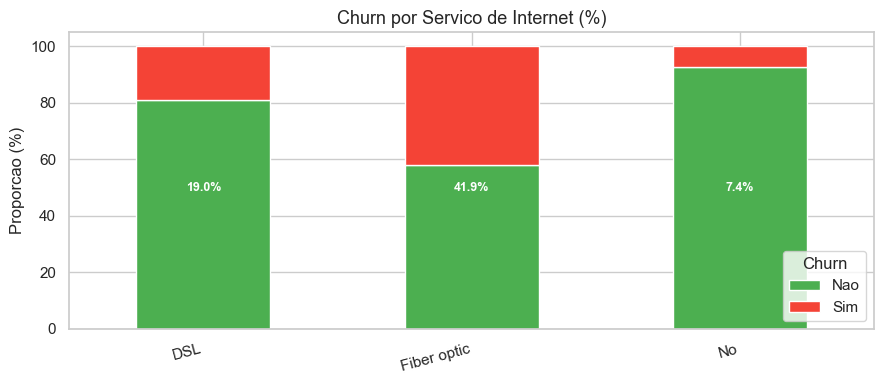

In [16]:
plot_churn_por_categoria(
    df, "Servico_Internet",
    titulo="Churn por Servico de Internet (%)",
    save_path="graficos/03_churn_por_internet.png"
)

### 6.4 Churn por Metodo de Pagamento

**Hipotese:** Electronic Check tem maior churn (menos automatizado).
Pagamentos automaticos (cartao, debito) tendem a reter melhor.

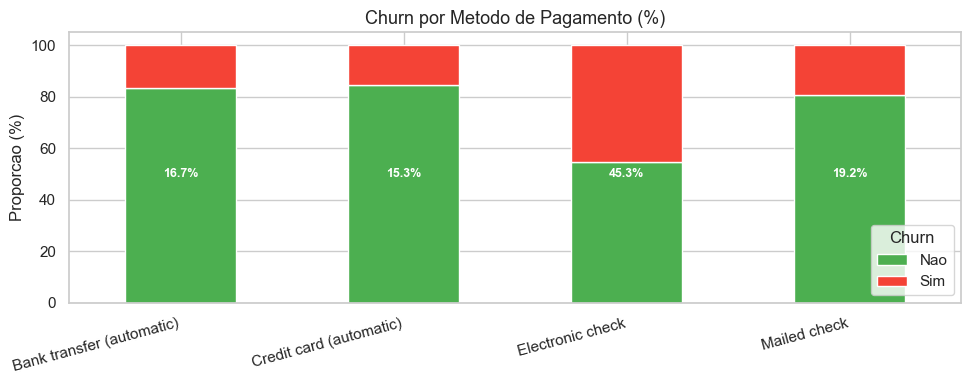

In [17]:
plot_churn_por_categoria(
    df, "Metodo_Pagamento",
    titulo="Churn por Metodo de Pagamento (%)",
    figsize=(10, 4),
    save_path="graficos/04_churn_por_pagamento.png"
)

### 6.5 Churn por Genero

Verificamos se ha diferenca relevante entre segmentos demograficos basicos.

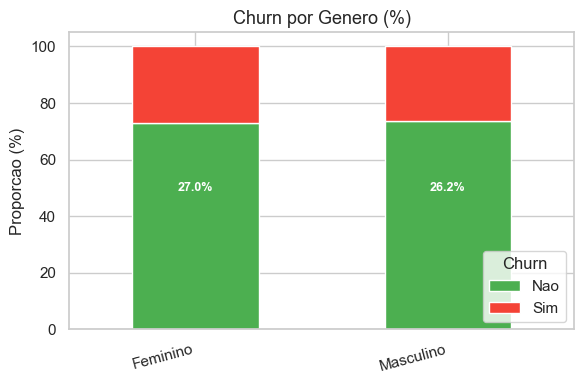

In [18]:
plot_churn_por_categoria(
    df, "Genero",
    titulo="Churn por Genero (%)",
    figsize=(6, 4),
    save_path="graficos/05_churn_por_genero.png"
)

### 6.6 Variaveis Numericas vs Churn (Boxplots)

- **Tempo_Contrato_Meses**: proxy de fidelizacao.
- **Faturamento_Mensal**: proxy de plano contratado.

C:\Users\neves\AppData\Local\Temp\ipykernel_14392\3213557473.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["Nao", "Sim"])
C:\Users\neves\AppData\Local\Temp\ipykernel_14392\3213557473.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(["Nao", "Sim"])


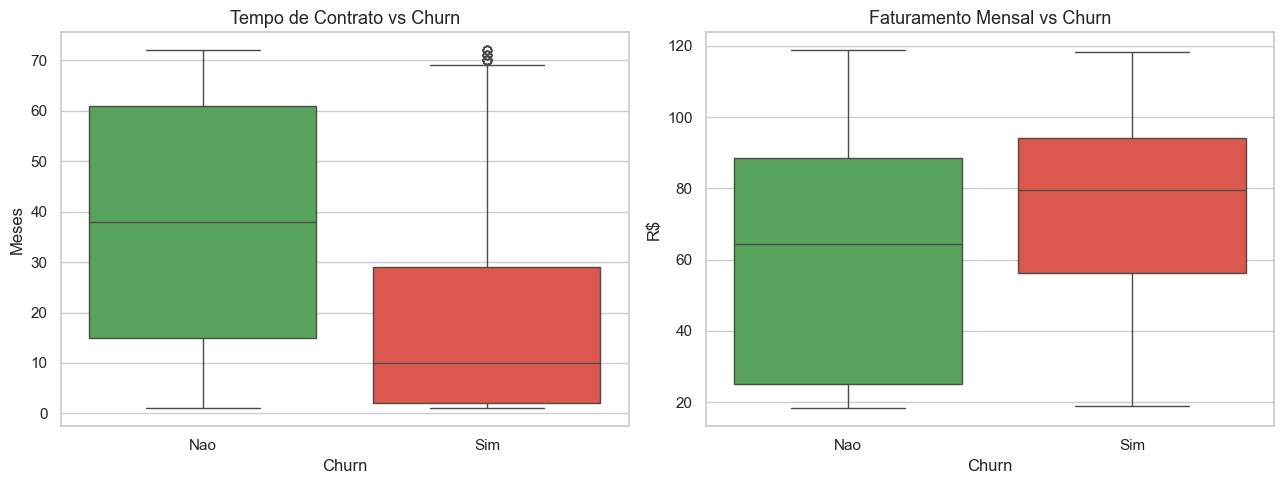

In [19]:
PALETTE = {0: "#4CAF50", 1: "#F44336"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Churn", y="Tempo_Contrato_Meses", hue="Churn", palette=PALETTE, legend=False, ax=axes[0])
axes[0].set_title("Tempo de Contrato vs Churn", fontsize=13)
axes[0].set_xticklabels(["Nao", "Sim"])
axes[0].set_xlabel("Churn")
axes[0].set_ylabel("Meses")

sns.boxplot(data=df, x="Churn", y="Faturamento_Mensal", hue="Churn", palette=PALETTE, legend=False, ax=axes[1])
axes[1].set_title("Faturamento Mensal vs Churn", fontsize=13)
axes[1].set_xticklabels(["Nao", "Sim"])
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("R$")

plt.tight_layout()
plt.savefig("graficos/06_box_numericas_vs_churn.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.7 Distribuicao do Total Gasto por Churn

Clientes retidos acumulam maior gasto (maior LTV).
A curva KDE permite ver a sobreposicao entre os grupos.

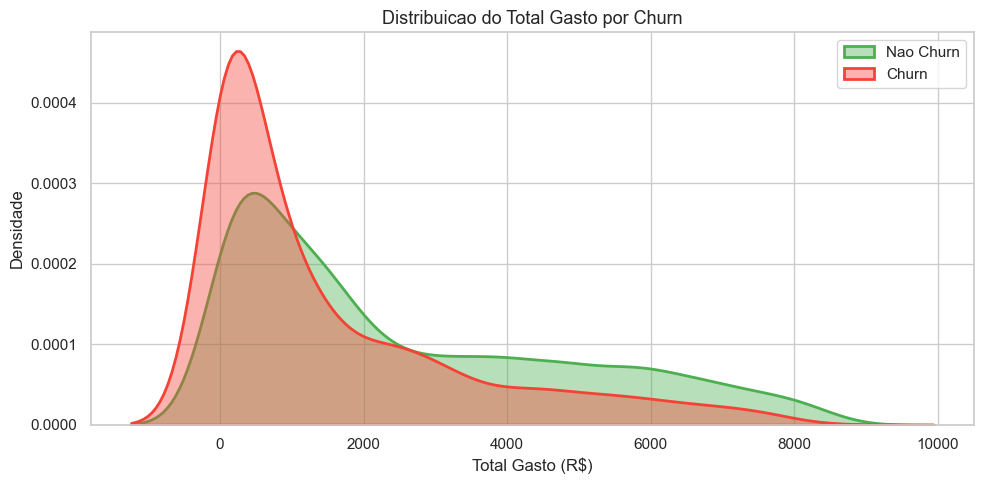

In [20]:
plt.figure(figsize=(10, 5))

for churn_val, label, color in [
    (0, "Nao Churn", "#4CAF50"),
    (1, "Churn",     "#F44336"),
]:
    subset = df.loc[df["Churn"] == churn_val, "Total_Gasto"]
    sns.kdeplot(subset, label=label, color=color, fill=True, alpha=0.4, linewidth=2)

plt.title("Distribuicao do Total Gasto por Churn", fontsize=13)
plt.xlabel("Total Gasto (R$)")
plt.ylabel("Densidade")
plt.legend()
plt.tight_layout()
plt.savefig("graficos/07_kde_total_gasto_churn.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.8 Matriz de Correlacao (Heatmap)

Identifica relacoes lineares entre variaveis numericas.
> Correlacao nao implica causalidade, mas guia hipoteses para o modelo.

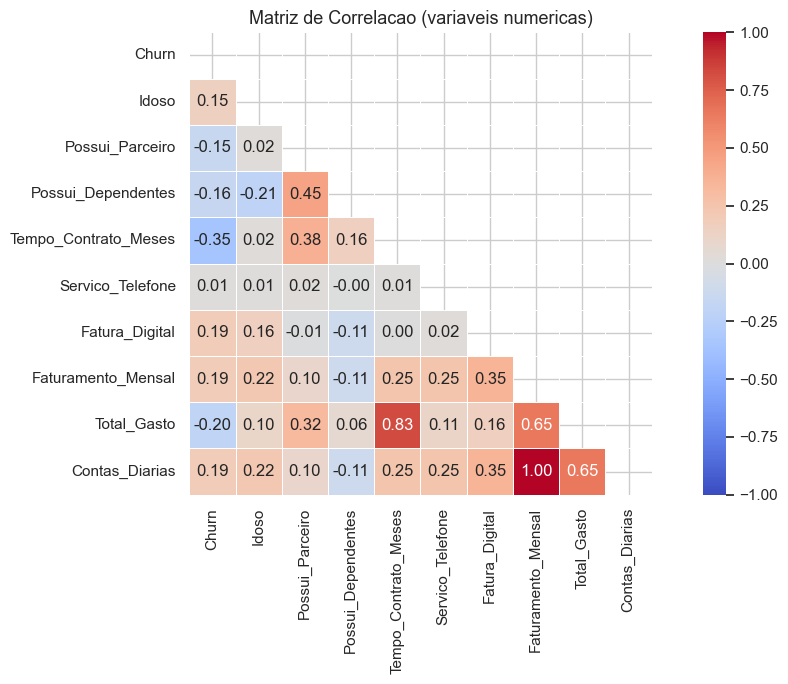

In [21]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(11, 7))
sns.heatmap(
    corr, annot=True, cmap="coolwarm", fmt=".2f",
    mask=mask, vmin=-1, vmax=1, linewidths=0.5, square=True
)
plt.title("Matriz de Correlacao (variaveis numericas)", fontsize=13)
plt.tight_layout()
plt.savefig("graficos/08_heatmap_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

**Insights esperados:**
- `Tempo_Contrato_Meses` correlacao **negativa** com `Churn` -> churn maior em clientes novos.
- `Total_Gasto` altamente correlacionado com `Tempo_Contrato_Meses`.
- `Faturamento_Mensal` pode ter correlacao **positiva** com `Churn`.

---
## 7) Insights e Recomendacoes (Executivo)

### Principais achados

| # | Achado | Evidencia |
|---|--------|-----------|
| 1 | **Contratos Mensais** concentram a maior taxa de churn | Grafico 6.2 |
| 2 | Clientes em **Fiber Optic** apresentam churn elevado | Grafico 6.3 |
| 3 | **Electronic Check** esta associado a mais cancelamentos | Grafico 6.4 |
| 4 | Churn e mais frequente em clientes com **baixo tempo de contrato** | Boxplot 6.6 |
| 5 | Clientes retidos acumulam **maior Total Gasto** (LTV superior) | KDE 6.7 |

### Recomendacoes Acionaveis

1. **Retencao nos primeiros 90 dias**  
   Onboarding ativo, suporte prioritario e pesquisa de satisfacao nos primeiros 3 meses.

2. **Incentivo a contratos anuais/bienais**  
   Descontos progressivos, cashback e beneficios exclusivos para migracao de plano.

3. **Foco no segmento Fiber Optic**  
   Revisar percepcao de custo-beneficio; campanha de qualidade e suporte tecnico.

4. **Incentivo ao pagamento automatico**  
   Debito automatico e cartao de credito estao associados a menor churn.

5. **Modelo preditivo como proximo passo**  
   O `df` produzido por este pipeline esta pronto para alimentar um modelo
   supervisionado (Logistic Regression, Random Forest, etc.).

---


In [22]:

# Exportar DataFrame tratado para CSV
csv_path = "telecom_x_eda.csv"
df.to_csv(csv_path, index=False, encoding="utf-8-sig")
print(f"Arquivo exportado: {csv_path}  |  Linhas: {len(df)}  |  Colunas: {df.shape[1]}")


Arquivo exportado: telecom_x_eda.csv  |  Linhas: 7032  |  Colunas: 22
